In [1]:
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import jax
from jax import config, jit
import jax.numpy as jnp
from jax.lax import fori_loop, while_loop

In [3]:
from scripts.figures import set_rc_parameters

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

In [6]:
class MCMC:
    """Metropolis sampler in N dimensions."""
    
    def __init__(
            self, neq: int, nav: int, nvoid: int, ndim: int, sig: float,
            x_in: float, loss: callable
    ):
        """Set instance attributes of sampler."""

        self.neq = neq
        self.nav = nav
        self.nvoid = nvoid
        self.ndim = ndim
        self.nsteps = self.nvoid * (self.neq + self.nav)
        self.sig = sig
        # Initial parameters
        self.x_in = x_in
        # Loss function with respect to parameters
        self.loss = loss

    def walk(self, key):
        """Function that performs the full Metropolis walk, and returns the path
        and the acceptance.
        """
        
        @jit
        def step(i, loop_carry_i):
            
            x_o, key_o, acc_s, x_s = loop_carry_i              
            loss_o = self.loss(x_o)
            key_o, key_input = random.split(key_o)
            x_n = x_o + self.sig * random.normal(key_input, shape=[self.ndim])
            loss_n = self.loss(x_n)
            prob = jnp.exp( ( loss_n - loss_o ) )
            key_o, key_input = random.split(key_o)
            accept = jnp.greater(prob, random.uniform(key_input))
            x_o = jnp.where(accept.reshape([1]), x_n, x_o)
            acc_s = acc_s.at[i // self.nvoid].set(accept.astype('float32'))
            x_s = x_s.at[i // self.nvoid,:].set(x_o)
            
            return x_o, key_o, acc_s, x_s
        
        acc_s = jnp.zeros(shape=[self.neq + self.nav])
        x_s = jnp.zeros(shape=[self.neq + self.nav,self.ndim])      
        key_o, key_input = random.split(key)
        x_o = self.x_in
        x_o, key_o, acc_s, x_s = fori_loop(0, self.nsteps, step,
                                           (x_o, key_o, acc_s, x_s))
        
        acc_s = acc_s[self.neq:]
        x_s = x_s[self.neq:,:]
        
        return x_s, acc_s  

### Testing MC integration with Metropolis and sampling uniformly over $[a,b]$

Monte Carlo Integral Estimate: 0.9998


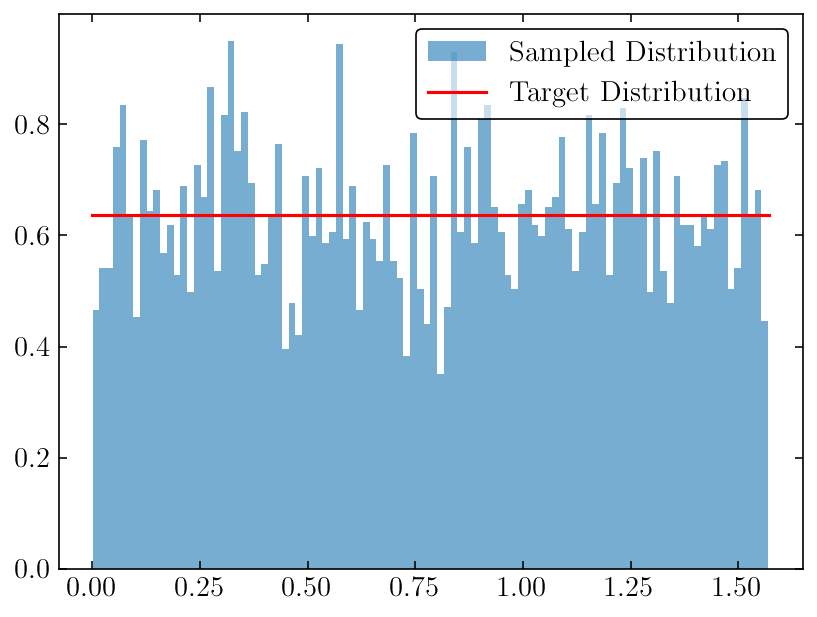

In [7]:
key = jax.random.PRNGKey(0)
a, b = 0, jnp.pi / 2  # Interval boundaries
num_samples = 10000

def f(x):
    return jnp.sin(x)  # Example function to integrate

def target_distribution(x):
    # Uniform distribution over [a, b]
    return jnp.where((x >= a) & (x <= b), 1 / (b - a), 0)

def metropolis_integration(key, num_samples, a, b, sig=0.5):
    samples = []
    x_current = a + (b - a) * jax.random.uniform(key)  # Initial point
    key, subkey = jax.random.split(key)
    
    for _ in range(num_samples):
        key, subkey = jax.random.split(key)
        x_proposal = x_current + jax.random.normal(subkey) * sig  # Proposal step
        
        # Acceptance probability
        acceptance_ratio = target_distribution(x_proposal) / target_distribution(x_current)
        acceptance_prob = jnp.minimum(1.0, acceptance_ratio)

        key, subkey = jax.random.split(key)
        if jax.random.uniform(subkey) < acceptance_prob:
            x_current = x_proposal

        # Store sample if within bounds
        if a <= x_current <= b:
            samples.append(x_current)

    return jnp.array(samples)

# samples = metropolis_integration(key, num_samples, a, b)
samples = metropolis_integration(key, num_samples, a, b, sig=jnp.pi/2)
integral_estimate = (b - a) * jnp.mean(f(samples))

print(f"Monte Carlo Integral Estimate: {integral_estimate:.4f}")

# Plotting
plt.hist(samples, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 100)
plt.plot(x, target_distribution(x), label="Target Distribution", color='red')
plt.legend()
plt.show()

In [11]:
class MCIntegration:
    
    def __init__(self, integrand, num_samples, sig=1.0):
        
        # Set integrand as instance attribute
        self.integrand = integrand
        self.num_samples = num_samples
        self.sig = sig
        
        self.acc_s = jnp.zeros(num_samples)
        self.x_s = jnp.zeros(num_samples)
        
    @partial(jit, static_argnums=(0,))
    def integrate(self, a, b):

        # Get samples over [a, b]
        key = jax.random.PRNGKey(0)
        self.acc_s, self.x_s = self.metropolis_walk(key, a, b)
        
        # Integrate over the interval [a, b]
        vol = b - a
        # integral = vol * jnp.mean(integrand(self.x_s))
        # integral = vol * jnp.mean(integrand(self.x_s) / jnp.exp(self.x_s))
        l = (b - a) / 2
        integral = (vol * jnp.mean(integrand(self.x_s))
                    / self.weight(self.x_s, a, b, l))
        
        return self.acc_s, self.x_s, integral

    @partial(jit, static_argnums=(0,))
    def metropolis_walk(self, key, a, b):

        key, _ = jax.random.split(key)
        
        # Initial point
        x_o = a + (b - a) * jax.random.uniform(key)
        
        # Loop over number of samples
        x_o, key, self.acc_s, self.x_s = fori_loop(
            0, self.num_samples, self.step, (x_o, key, self.acc_s, self.x_s)
        )
        
        return self.acc_s, self.x_s
        
    @partial(jit, static_argnums=(0,))
    def step(self, i, loop_carry):
            
        x_o, key, self.acc_s, self.x_s = loop_carry             
        f_o = self.integrand(x_o)
        key, subkey = jax.random.split(key)
        x_n = x_o + self.sig * jax.random.normal(subkey)
        f_n = self.integrand(x_n)

        key, subkey = jax.random.split(key)
        
#         ratio = jnp.abs(f_n / f_o)
#         ratio = jnp.exp(-x_n ** 2) / jnp.exp(-x_o ** 2)
#         accept = jnp.greater(ratio, jax.random.uniform(subkey))
        
        # Only store if in bounds
        # bounds = jnp.logical_and(x_n >= a, x_n <= b)
        # cond = jnp.logical_and(accept, bounds)
#         cond = accept
#         x_o = jnp.where(cond, x_n, x_o)
        
#         # This will accept all samples in [a, b]
#         acceptance_ratio = (self.target_distribution(x_n, a, b)
#                             / self.target_distribution(x_o, a, b))
#         accept = jnp.minimum(1.0, acceptance_ratio)
#         x_o = jnp.where(jax.random.uniform(subkey) < accept, x_n, x_o)

        l = (b - a) / 2
        acceptance_ratio = self.weight(x_n, a, b, l) / self.weight(x_o, a, b, l)
        accept = jnp.minimum(1.0, acceptance_ratio)
        x_o = jnp.where(jax.random.uniform(subkey) < accept, x_n, x_o)
        
        self.acc_s = self.acc_s.at[i].set(accept.astype('float32'))
        self.x_s = self.x_s.at[i].set(x_o)
            
        return x_o, key, self.acc_s, self.x_s
    
    @partial(jit, static_argnums=(0,))
    def target_distribution(self, x, a, b):
        """Uniform distribution over [a, b]."""
        
        # Check if a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return jnp.where(cond, 1 / (b - a), 0)
    
    @partial(jit, static_argnums=(0,))
    def weight(self, x, a, b, l):
        """Weighting Gaussian with variance l^2."""
        
        gaussian = jnp.exp(-(x / l) ** 2 / 2) / jnp.sqrt(2 * jnp.pi * l ** 2)
        
        # Make sure a <= x <= b
        cond = jnp.logical_and(x >= a, x <= b)
        
        return jnp.where(cond, gaussian, 0)

[3.90925486 3.90925486 2.81507841 ... 2.46240844 2.46240844 2.46240844]


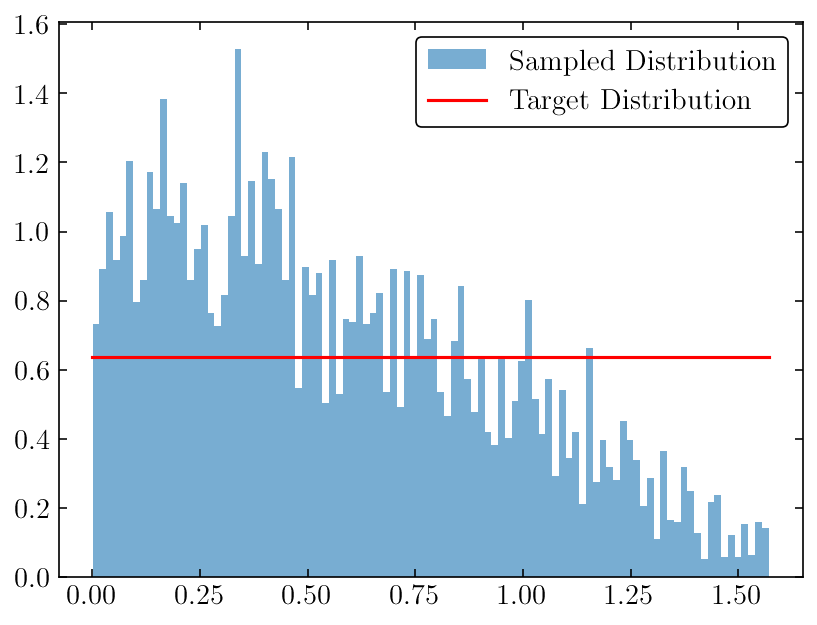

In [12]:
@jit
def integrand(x):
    return jnp.cos(x)

key = jax.random.PRNGKey(0)
a, b = 0, jnp.pi / 2  # Interval boundaries
num_samples = 10000

mc_integration = MCIntegration(integrand, num_samples, sig=b)

acc_s, x_s, integral = mc_integration.integrate(a, b)

print(integral)

# Plotting
plt.hist(x_s, bins=100, density=True, alpha=0.6, label="Sampled Distribution")
x = jnp.linspace(a, b, 100)
plt.plot(x, target_distribution(x), label="Target Distribution", color='red')
plt.legend()
plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def metropolis_sampling(target_pdf, proposal_std, n_samples, x0=0.0):
    samples = []
    x = x0
    for _ in range(n_samples):
        x_new = x + np.random.normal(0, proposal_std)
        accept_ratio = min(1.0, target_pdf(x_new) / target_pdf(x))
        if np.random.rand() < accept_ratio:
            x = x_new
        samples.append(x)
    return np.array(samples)

def gaussian_pdf(x, sigma):
    return np.exp(-x**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)

# Define your integrand
def integrand(x):
    return x**2  # Example function to integrate

# Parameters
sigma = 1.0
n_samples = 100000
proposal_std = 1.0

# Target PDF is the Gaussian you want to sample from
target_pdf = lambda x: gaussian_pdf(x, sigma)

# Generate samples
samples = metropolis_sampling(target_pdf, proposal_std, n_samples)

# Estimate the integral: f(x) / p(x), averaged over samples
weights = integrand(samples) / gaussian_pdf(samples, sigma)
integral_estimate = np.mean(weights)

print(f"Estimated integral: {integral_estimate:.5f}")

Estimated integral: 112.34229
